<a href="https://colab.research.google.com/github/Dipanjan-Chaudhuri/Exact-Diagonalization-on-1D-spin-chain/blob/main/ED_of_1D_Quantum_Spin_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective:

Build an ED solver in Python that uses bitwise state representation, symmetry sector decomposition, and sparse matrix methods to calculate ground state properties and entanglement entropy.

We will be using the Heisenberg XXZ 1D spin-1/2 chain,

$$ H = \sum_{i=1}^{N} \Big[\frac{J}{2}(S^{+}_{i}S^{-}_{i+1} + S^{-}_{i}S^{+}_{i+1}) + \Delta \ (S^{z}_{i}S^{z}_{i+1})\Big] $$

Looking at this Hamiltonian, it is clear that the total magnetization in the $z$-direction $m^z = \sum_{i=1}^{N} S^{z}_{i}$ remains conserved because, $$[H,m^z] = 0.$$

Due to this, the Hamiltonian is fractured into a block diagonal form, where each block corresponds to a specific symmetry sector (specific value of $m^z$). This fact can be used to solve for the ground state of the Hamiltonian be exactly diagonalizing the Hamiltonian block that corresponds to the ground state configuration of spins.  

This is computationally much more feasible as instead of a matrix that is $2^{N} \times 2^{N}$ we have to diagonalize a much smaller block corresponding to the symmetry sector we are looking for.

This is the essential idea behind **Exact Diagonalization** or **ED**.

In [2]:
# Libraries
# ---------
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.linalg import svd
import matplotlib.pyplot as plt

In [3]:
'''
Generating the basis on which we would construct our Hamiltonian.
This is not the true hamiltonian, but the block corrosponding to a specific number of up-spins N_up.
That is, we are already restricting ourselves to a symmetry block corresponding to some m^z.
'''

def generate_basis(N,N_up):
  basis = []
  for state in range(2**N):
    if bin(state).count('1') == N_up:
      # Counting the number of up spins in the state, in bitwise representation.
      basis.append(state)

  state_to_index = {state : i for i,state in enumerate(basis)}
  # The above dictionary maps the states in our chosen symmetry block to indices according to their position in the list of basis. This helps us find the specific state in the basis from it's index later when the Hamiltonian is flipping bits of the basis states.

  return basis, state_to_index

In [4]:
def build_hamiltonian(N, basis, state_to_index, J = 1.0 , Delta = 1.0):
  dim = len(basis)
  H = sp.lil_matrix((dim,dim), dtype = np.float64)
  # LIL matrix allows for computationally cheap addition of elements in a sparse matrix. Element is appended, instead of the matrix being reconstructed everytime.

  for i,state in enumerate(basis):
    for site in range(N):

      next_site = (site + 1) % N    # Periodic Boundary conditions

      bit1 = (state >> site) & 1
      bit2 = (state >> next_site) & 1

      if bit1 == bit2 : # Spins are aligned
        H[i,i] += Delta * 0.25

      else :   # Spin anti-aligned
        H[i,i] -= Delta * 0.25

        flipped_state = state^(1 << site | 1 << next_site)    # Check multi-line comment below ⬇️
        j = state_to_index[flipped_state]
        H[i,j] += J * 0.5

  return H.tocsr()


  '''
  The factor (1 << site | 1 << next_site) gives us the positions of the two anti-aligned spins,
  the XOR operator (^) does the flipping part by comparing the spin state with the mask containing the positions of the anti-aligned spins,
  so that they can be flipped without affecting the other spins at other lattice sites.
  '''

In [5]:
def main():

  N = 14
  N_up = N//2     # m^z = 0
  J = 1.0         # Exchange coupling
  Delta = 1.0     # Anisotropy

  # Generating the Basis

  basis,state_to_index = generate_basis(N,N_up)
  dim = len(basis)

  print(f"Restricted Hilbert Space dimension = {dim}")

  # Building the Hamiltonian

  H = build_hamiltonian(N,basis,state_to_index,J,Delta)

  # Exact Diagonalization (Lanczos)
  # k = 1 gives the ground state
  # which = 'SA' searches for Smallest Algebraic eigenvalues
  eigenenergies, eigenvectors = eigsh(H, k = 1, which = 'SA')

  E_0 = eigenenergies[0]
  psi_0 = eigenvectors[:,0]

  entropy = half_chain_entanglement_entropy(N, psi_0, basis)
  print(f"Ground State Energy = {E_0}")
  print(f"Half-chain Entanglement Entropy = {entropy}")

In [6]:
from scipy.linalg import svd

def half_chain_entanglement_entropy(N, psi_0, basis):

  # To get the half chain entanglement entropy, we need to map psi_0 back into the full Hilbert space

  full_psi = np.zeros(2**N, dtype=np.float64)

  for i, state in enumerate(basis):
      full_psi[state] = psi_0[i]

  N_A = N//2        # Left sites
  N_B = N - N_A     # Right sites

  full_psi = full_psi.reshape((2**N_A,2**N_B))

  # Computing SVD
  S = svd(full_psi, compute_uv=False)

  eigenvalues = S**2

  eigenvalues = eigenvalues[eigenvalues > 1e-12]
  # Avoiding ln(0) errors
  entropy = -np.sum(eigenvalues * np.log(eigenvalues))
  # Entanglement entropy

  return entropy

In [7]:
if __name__ == "__main__":
  main()

Restricted Hilbert Space dimension = 3432
Ground State Energy = -6.26354953354703
Half-chain Entanglement Entropy = 1.2352922409192217


Scanning phase transition for N=18...


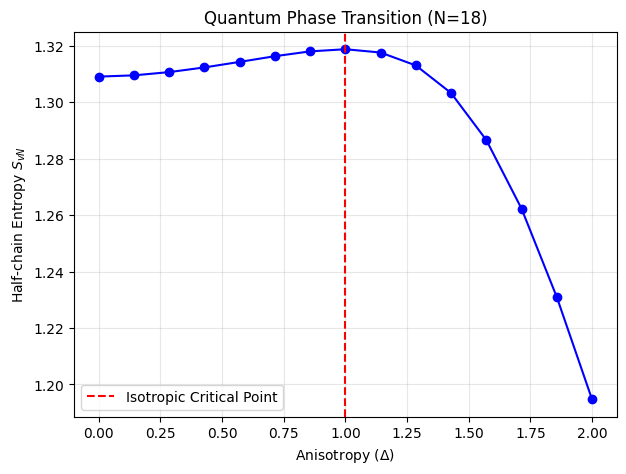

In [8]:
# ---------------------------------------------------------
# Phase Transition Scanner (Entropy vs Delta)
# ---------------------------------------------------------
N_scan = 18
N_up_scan = N_scan // 2
J_scan = 1.0
deltas = np.linspace(0.0, 2.0, 15)
entropies = []

# Basis only needs to be generated once for a fixed N
basis_scan, state_to_index_scan = generate_basis(N_scan, N_up_scan)

print(f"Scanning phase transition for N={N_scan}...")
for d in deltas:
    H_scan = build_hamiltonian(N_scan, basis_scan, state_to_index_scan, J_scan, d)
    eigenenergies_scan, eigenvectors_scan = eigsh(H_scan, k=1, which='SA')
    psi_0_scan = eigenvectors_scan[:, 0]

    entropy = half_chain_entanglement_entropy(N_scan, psi_0_scan, basis_scan)
    entropies.append(entropy)

plt.figure(figsize=(7, 5))
plt.plot(deltas, entropies, marker='o', color='b')
plt.axvline(1.0, color='r', linestyle='--', label='Isotropic Critical Point')
plt.xlabel(rf'Anisotropy ($\Delta$)')
plt.ylabel(r'Half-chain Entropy $S_{vN}$')
plt.title(f'Quantum Phase Transition (N={N_scan})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('phase_transition.png', dpi=300, bbox_inches='tight')
plt.show()

Performing finite-size scaling...


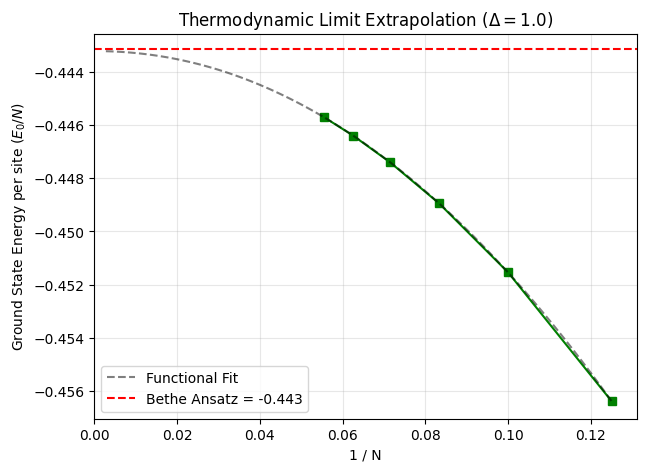

In [28]:
# ---------------------------------------------------------
# Finite-Size Scaling (Energy/site vs 1/N)
# ---------------------------------------------------------
sizes = [8, 10, 12, 14, 16, 18]
energies_per_site = []
inv_N = [1/n for n in sizes]
J_scale = 1.0
Delta_scale = 1.0
bethe_ansatz = 0.25 - np.log(2)

print("Performing finite-size scaling...")
for n in sizes:
    n_up = n // 2
    basis_scale, state_to_index_scale = generate_basis(n, n_up)
    H_scale = build_hamiltonian(n, basis_scale, state_to_index_scale, J_scale, Delta_scale)

    eigenenergies_scale, _ = eigsh(H_scale, k=1, which='SA')
    energies_per_site.append(eigenenergies_scale[0] / n)

plt.figure(figsize=(7, 5))
plt.plot(inv_N, energies_per_site, marker='s', color='g')

from scipy.optimize import curve_fit

# Defining the polynomial function to fit
def fitting_func(x, a, b, c):
    return a*x**b + c

x_data = np.array(inv_N)
y_data = np.array(energies_per_site)

# Perform the curve fit
popt, pcov = curve_fit(fitting_func, x_data, y_data)
a_fit, b_fit, c_fit = popt

x_fit = np.linspace(min(x_data) * 0.05, max(x_data), 100)
y_fit = fitting_func(x_fit, a_fit, b_fit, c_fit)

# 5. Plot the new fit
plt.plot(x_fit, y_fit, '--k', alpha=0.5, label=f'Functional Fit')

plt.axhline(y = bethe_ansatz , color = "r", linestyle = "--", label = rf"Bethe Ansatz = {bethe_ansatz:.3f}")
plt.legend()
plt.xlabel('1 / N')
plt.ylabel(r'Ground State Energy per site ($E_0 / N$)')
plt.title(r'Thermodynamic Limit Extrapolation ($\Delta=1.0$)')
plt.xlim(left=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('finite_scaling.png', dpi=300, bbox_inches='tight')
plt.show()